# Adversarial Robustness of Machine Learning-Based Intrusion Detection Systems

This notebook is the local-only version of our project pipeline. It assumes the raw CICIDS2017 CSV files are in the **same folder as this notebook**.

It combines:

- Amogh's adversarial ML pipeline: PyTorch MLP, FGSM, PGD, and transferability tests.
- Our preprocessing pipeline: safer cleaning, stratified split, confusion matrices, classification reports, and saved artifacts.

The notebook does **not** depend on Kaggle paths or pre-cleaned CSV files.

## 1. Project Goal

Machine-learning intrusion detection systems can perform very well on clean benchmark traffic, but they may be vulnerable to adversarial perturbations. In this experiment, we:

1. Load raw local CICIDS2017 CSV files.
2. Clean and sanitize the data into trainable numeric features.
3. Train classical baseline intrusion-detection models.
4. Train a neural-network IDS model.
5. Evaluate all models on clean test data.
6. Generate adversarial test samples using FGSM and PGD against the neural network.
7. Test whether the adversarial examples transfer to Logistic Regression and Random Forest.

The default target is **broad multiclass classification**, which groups raw CICIDS2017 labels into categories such as `Normal Traffic`, `DDoS`, `DoS`, `Port Scanning`, `Brute Force`, `Web Attacks`, and `Bots`.

## 2. Setup and Configuration

Put your downloaded CICIDS2017 CSV files in the same folder as this notebook. The notebook will search only this local folder.

In [44]:
import json
import random
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

# -----------------------------
# Local data settings
# -----------------------------
# This notebook only searches the folder where the notebook is running.
# Do not add Kaggle paths or external paths here.
LOCAL_CSV_PATTERN = "*.csv"

# Files produced by this notebook should not be loaded as raw input data later.
EXCLUDED_CSV_NAMES = {
    "results_summary.csv",
    "processed_cicids2017_local.csv",
}

# Label options:
#   "broad_multiclass" -> groups raw CICIDS labels into broad classes for the project narrative
#   "raw_multiclass"   -> keeps original CICIDS labels, such as DoS Hulk, PortScan, DDoS
#   "binary"           -> BENIGN vs ATTACK
LABEL_MODE = "broad_multiclass"

# Drop classes with fewer than this many rows before stratified splitting.
# Stratified train/test split requires each class to have at least 2 samples.
MIN_SAMPLES_PER_CLASS = 2

# Drop numeric feature columns with too much missingness after coercion.
MAX_MISSING_RATIO = 0.80

# Optional clipping of extreme numeric values after train/test split.
# This is fit on training data only to avoid leakage.
CLIP_EXTREME_VALUES = True
CLIP_LOWER_QUANTILE = 0.001
CLIP_UPPER_QUANTILE = 0.999

# -----------------------------
# Experiment settings
# -----------------------------
TEST_SIZE = 0.20
BATCH_SIZE = 1024
MLP_EPOCHS = 5
MLP_LEARNING_RATE = 1e-3
DROPOUT = 0.30

# To keep classical baselines fast, train Logistic Regression and Random Forest
# on a stratified subset when the training data is very large.
SKLEARN_TRAIN_LIMIT = 300_000

# Adversarial attack settings from Amogh's first pass.
FGSM_EPSILON = 0.05
PGD_EPSILON = 0.05
PGD_ALPHA = 0.01
PGD_STEPS = 10

OUTPUT_DIR = Path("outputs")
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Searching for local CSV files with pattern: {LOCAL_CSV_PATTERN}")

Using device: cpu
Searching for local CSV files with pattern: *.csv


## 3. Data Loading and Cleaning Helpers

This section assumes raw CICIDS2017 CSV files are in the same folder as the notebook.

The cleaning approach is designed to create usable training/testing data while avoiding obvious leakage:

- Column names are stripped and duplicate columns are removed.
- Raw labels are cleaned and optionally grouped into broader attack categories.
- Non-feature metadata columns such as IP addresses, flow IDs, and timestamps are removed.
- Features are coerced to numeric values.
- Infinite values are replaced with missing values.
- All-null, mostly-missing, and constant feature columns are removed.
- Rare classes that cannot support stratified splitting are removed.
- Median imputation, outlier clipping, and scaling are fit only on the training split.

In [45]:
def find_local_csv_files():
    """Find CSV files in the same folder as the notebook, excluding generated outputs."""
    csv_files = []
    for path in Path(".").glob(LOCAL_CSV_PATTERN):
        if path.is_file() and path.name not in EXCLUDED_CSV_NAMES:
            if not str(path).startswith("outputs"):
                csv_files.append(path)
    return sorted(csv_files)


def read_csv_robust(path):
    """Read a CSV file with a small fallback for encoding issues."""
    try:
        return pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, low_memory=False, encoding="latin1")


def normalize_column_names(df):
    """Strip whitespace and remove duplicated columns."""
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def find_label_column(df):
    """Find the CICIDS label column even if whitespace or casing differs."""
    for col in df.columns:
        if col.strip().lower() == "label":
            return col
    raise ValueError("Could not find a 'Label' column. Make sure these are raw CICIDS2017 CSV files.")


def clean_label_text(value):
    """Normalize label text while preserving human-readable class names."""
    value = str(value).strip()
    value = value.replace("\u2013", "-").replace("\u2014", "-")
    value = value.replace("\ufffd", "-")
    value = re.sub(r"\s+", " ", value)
    return value


def normalize_label_key(value):
    """Create a robust key for mapping raw CICIDS labels."""
    value = clean_label_text(value).lower()
    value = re.sub(r"[^a-z0-9]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()
    return value


def map_to_broad_attack_type(label):
    """Map raw CICIDS2017 labels to broad project categories."""
    key = normalize_label_key(label)

    if key == "benign":
        return "Normal Traffic"
    if key == "ddos":
        return "DDoS"
    if key == "portscan":
        return "Port Scanning"
    if key.startswith("dos ") or key in {"dos", "heartbleed"}:
        return "DoS"
    if "patator" in key:
        return "Brute Force"
    if key.startswith("web attack") or "web attack" in key:
        return "Web Attacks"
    if key == "bot":
        return "Bots"
    if "infiltration" in key:
        return "Infiltration"

    return "Other Attacks"


def build_target(raw_labels, label_mode=LABEL_MODE):
    """Build the target series according to the configured label mode."""
    cleaned = raw_labels.astype(str).map(clean_label_text)

    if label_mode == "binary":
        return cleaned.map(lambda label: "BENIGN" if normalize_label_key(label) == "benign" else "ATTACK")

    if label_mode == "raw_multiclass":
        return cleaned

    if label_mode == "broad_multiclass":
        return cleaned.map(map_to_broad_attack_type)

    raise ValueError("LABEL_MODE must be 'broad_multiclass', 'raw_multiclass', or 'binary'.")


def get_metadata_columns(columns):
    """Return columns that should not be used as numeric ML features."""
    metadata_names = {
        "flow id",
        "source ip",
        "src ip",
        "destination ip",
        "dst ip",
        "source port",
        "src port",
        "destination port",
        "dst port",
        "timestamp",
        "date",
        "time",
        "label",
    }

    drop_cols = []
    for col in columns:
        normalized = col.strip().lower()
        if normalized in metadata_names:
            drop_cols.append(col)
        elif normalized.startswith("unnamed"):
            drop_cols.append(col)
    return drop_cols


def load_local_raw_cicids2017():
    """Load raw CICIDS2017 CSV files from the notebook folder and perform global sanitation."""
    csv_files = find_local_csv_files()
    if not csv_files:
        raise FileNotFoundError(
            "No CSV files were found in the same folder as this notebook. "
            "Place the raw CICIDS2017 CSV files beside the notebook and rerun this cell."
        )

    print("Found local CSV files:")
    for file in csv_files:
        print(f"  - {file.name}")

    frames = []
    for file in csv_files:
        temp = read_csv_robust(file)
        temp = normalize_column_names(temp)
        label_col = find_label_column(temp)
        if label_col != "Label":
            temp = temp.rename(columns={label_col: "Label"})
        temp["__source_file"] = file.name
        frames.append(temp)

    df = pd.concat(frames, ignore_index=True, sort=False)
    df = normalize_column_names(df)

    print(f"\nCombined raw shape before cleaning: {df.shape}")

    # Remove rows without a usable label.
    df["Label"] = df["Label"].map(clean_label_text)
    df = df[df["Label"].notna()]
    df = df[df["Label"].astype(str).str.len() > 0]

    # Drop duplicate rows after combining all daily files.
    before_dedup = len(df)
    df = df.drop_duplicates()
    print(f"Dropped duplicate rows: {before_dedup - len(df):,}")

    y = build_target(df["Label"], LABEL_MODE)

    # Remove metadata/non-generalizable fields before numeric conversion.
    drop_cols = get_metadata_columns(df.columns)
    drop_cols.append("__source_file")
    drop_cols = sorted(set(drop_cols))

    X = df.drop(columns=drop_cols, errors="ignore")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.apply(pd.to_numeric, errors="coerce")

    # Remove unusable feature columns.
    all_null_cols = X.columns[X.isna().all()].tolist()
    if all_null_cols:
        X = X.drop(columns=all_null_cols)

    missing_ratio = X.isna().mean()
    mostly_missing_cols = missing_ratio[missing_ratio > MAX_MISSING_RATIO].index.tolist()
    if mostly_missing_cols:
        X = X.drop(columns=mostly_missing_cols)

    constant_cols = [col for col in X.columns if X[col].nunique(dropna=True) <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)

    # Keep only rows with a target class that has enough examples for stratified splitting.
    class_counts = y.value_counts()
    valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index
    keep_mask = y.isin(valid_classes)
    dropped_rare = int((~keep_mask).sum())
    X = X.loc[keep_mask].reset_index(drop=True)
    y = y.loc[keep_mask].reset_index(drop=True)

    metadata = {
        "source": "local_raw_csv_files",
        "csv_files": [str(path) for path in csv_files],
        "label_mode": LABEL_MODE,
        "rows_after_cleaning": int(len(X)),
        "num_features_after_cleaning": int(X.shape[1]),
        "dropped_duplicate_rows": int(before_dedup - len(df)),
        "dropped_all_null_columns": all_null_cols,
        "dropped_mostly_missing_columns": mostly_missing_cols,
        "dropped_constant_columns": constant_cols,
        "dropped_metadata_columns": drop_cols,
        "dropped_rare_class_rows": dropped_rare,
        "max_missing_ratio": MAX_MISSING_RATIO,
    }

    print(f"Final feature shape before split: {X.shape}")
    print(f"Final target shape before split: {y.shape}")
    print(f"Dropped rare-class rows: {dropped_rare:,}")

    return X, y, metadata

## 4. Load the Dataset

The class distribution matters a lot for this project. CICIDS2017 is imbalanced, so we track more than accuracy later in the notebook.

In [46]:
X, y, data_metadata = load_local_raw_cicids2017()
feature_names = X.columns.tolist()

print("Dataset source:", data_metadata["source"])
print("Label mode:", data_metadata["label_mode"])
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

class_counts = y.value_counts().rename_axis("class_label").reset_index(name="count")
class_counts["percentage"] = 100 * class_counts["count"] / class_counts["count"].sum()
display(class_counts)

display(X.head())

Found local CSV files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv

Combined raw shape before cleaning: (2830743, 80)
Dropped duplicate rows: 256,479
Final feature shape before split: (2574264, 69)
Final target shape before split: (2574264,)
Dropped rare-class rows: 0
Dataset source: local_raw_csv_files
Label mode: broad_multiclass
Feature matrix shape: (2574264, 69)
Target shape: (2574264,)


,class_label,count,percentage
0,Normal Traffic,2148386,83.456320
1,DoS,193759,7.526773
2,DDoS,128016,4.972917
3,Port Scanning,90819,3.527960
4,Brute Force,9152,0.355519
5,Web Attacks,2143,0.083247
6,Bots,1953,0.075866
7,Infiltration,36,0.001398


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,3,2,0,12,0,6,6,6.0,0.0,0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0
1,109,1,1,6,6,6,6,6.0,0.0,6,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
2,52,1,1,6,6,6,6,6.0,0.0,6,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
3,34,1,1,6,6,6,6,6.0,0.0,6,...,0,20,0.0,0.0,0,0,0.0,0.0,0,0
4,3,2,0,12,0,6,6,6.0,0.0,0,...,1,20,0.0,0.0,0,0,0.0,0.0,0,0


## 5. Quick Class-Balance Check

Weighted F1 can look very strong on imbalanced data because large classes dominate the metric. We therefore also report macro F1 and balanced accuracy.

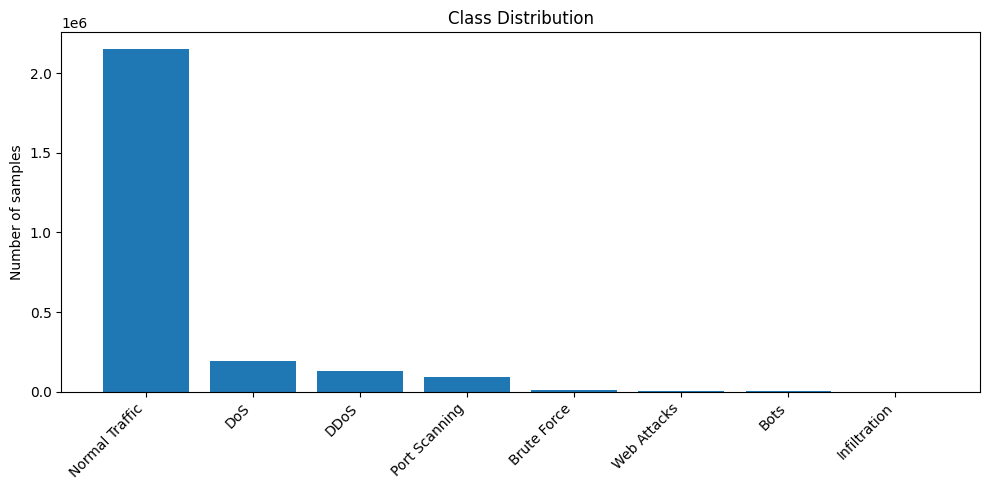

In [47]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts["class_label"].astype(str), class_counts["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

## 6. Encode Labels, Split Data, Impute, Clip, and Scale Features

We use a stratified split so the train and test sets preserve class proportions.

To avoid test-data leakage:

- Median imputation values are computed only from the training set.
- Extreme-value clipping bounds are computed only from the training set.
- The `StandardScaler` is fit only on the training set.

In [48]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.astype(str))
class_names = label_encoder.classes_.tolist()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

# Median imputation fit on training data only.
train_medians = X_train_df.median(numeric_only=True)
train_medians = train_medians.fillna(0)
X_train_clean = X_train_df.fillna(train_medians).fillna(0)
X_test_clean = X_test_df.fillna(train_medians).fillna(0)

# Optional outlier clipping fit on training data only.
if CLIP_EXTREME_VALUES:
    lower_bounds = X_train_clean.quantile(CLIP_LOWER_QUANTILE)
    upper_bounds = X_train_clean.quantile(CLIP_UPPER_QUANTILE)
    X_train_clean = X_train_clean.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
    X_test_clean = X_test_clean.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
else:
    lower_bounds = None
    upper_bounds = None

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Classes:")
for index, name in enumerate(class_names):
    print(f"  {index}: {name}")

print("\nTrain shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

train_distribution = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_distribution = pd.Series(y_test).value_counts(normalize=True).sort_index()
split_check = pd.DataFrame({
    "class_name": class_names,
    "train_percentage": train_distribution.values * 100,
    "test_percentage": test_distribution.values * 100,
})
display(split_check)

Classes:
  0: Bots
  1: Brute Force
  2: DDoS
  3: DoS
  4: Infiltration
  5: Normal Traffic
  6: Port Scanning
  7: Web Attacks

Train shape: (2059411, 69)
Test shape: (514853, 69)


,class_name,train_percentage,test_percentage
0,Bots,0.075847,0.075944
1,Brute Force,0.355539,0.355441
2,DDoS,4.972927,4.972876
3,DoS,7.526764,7.526809
4,Infiltration,0.001408,0.001360
5,Normal Traffic,83.456338,83.456249
6,Port Scanning,3.527950,3.527997
7,Web Attacks,0.083228,0.083325


## 7. Evaluation Helpers

These helpers keep the reporting consistent across models and attack settings.

In [49]:
results = []


def compute_metrics(y_true, y_pred):
    """Return the main metrics used in the project."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def add_result(model_name, condition, y_true, y_pred, notes=""):
    """Add one model/condition result to the global results list."""
    metrics = compute_metrics(y_true, y_pred)
    row = {
        "model": model_name,
        "condition": condition,
        **metrics,
        "notes": notes,
    }
    results.append(row)
    return row


def show_classification_summary(model_name, condition, y_true, y_pred):
    """Print metrics and a classification report."""
    metrics = compute_metrics(y_true, y_pred)
    print(f"{model_name} - {condition}")
    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


def plot_confusion(y_true, y_pred, title):
    """Plot a confusion matrix."""
    labels = np.arange(len(class_names))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    display_obj = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(9, 7))
    display_obj.plot(ax=ax, xticks_rotation=45, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def make_stratified_subset(X_array, y_array, max_samples, random_state=RANDOM_STATE):
    """Return a stratified subset for faster classical model training."""
    if max_samples is None or len(y_array) <= max_samples:
        return X_array, y_array

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        train_size=max_samples,
        random_state=random_state,
    )
    subset_indices, _ = next(splitter.split(X_array, y_array))
    return X_array[subset_indices], y_array[subset_indices]

## 8. Train Classical Baseline Models

We keep Logistic Regression and Random Forest because they make the project stronger: we can compare a neural model against non-neural baselines and later test whether adversarial examples transfer across model families.

For consistency with the adversarial samples, both classical baselines are trained on the scaled feature space.

Classical model training subset: (300000, 69)
Logistic Regression - clean
accuracy: 0.9869
weighted_f1: 0.9860
macro_f1: 0.6082
balanced_accuracy: 0.5868

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.99      0.75      0.85      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       0.97      0.91      0.94     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.99      1.00      0.99    429677
 Port Scanning       0.98      0.99      0.98     18164
   Web Attacks       0.96      0.05      0.10       429

      accuracy                           0.99    514853
     macro avg       0.74      0.59      0.61    514853
  weighted avg       0.99      0.99      0.99    514853



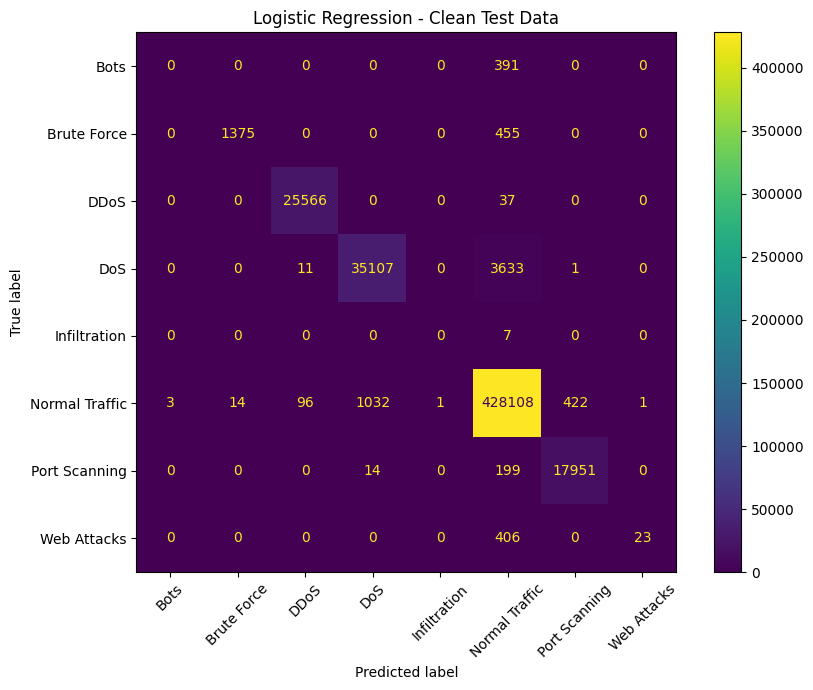

Random Forest - clean
accuracy: 0.9980
weighted_f1: 0.9979
macro_f1: 0.8357
balanced_accuracy: 0.7994

Classification report:
                precision    recall  f1-score   support

          Bots       0.79      0.38      0.52       391
   Brute Force       1.00      0.96      0.98      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      0.99      0.99     38752
  Infiltration       1.00      0.14      0.25         7
Normal Traffic       1.00      1.00      1.00    429677
 Port Scanning       0.99      1.00      0.99     18164
   Web Attacks       0.99      0.92      0.95       429

      accuracy                           1.00    514853
     macro avg       0.97      0.80      0.84    514853
  weighted avg       1.00      1.00      1.00    514853



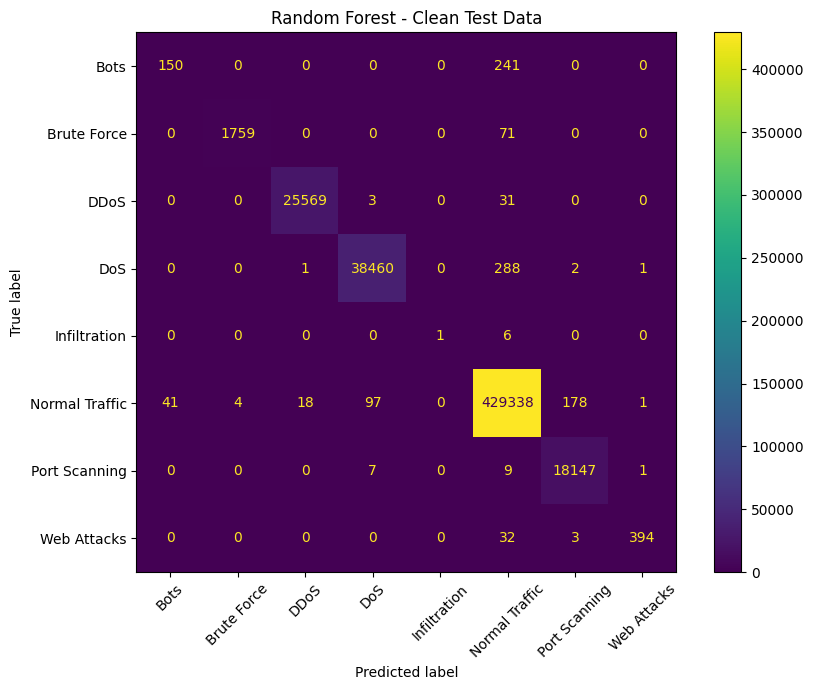

In [50]:
X_train_sklearn, y_train_sklearn = make_stratified_subset(
    X_train_scaled,
    y_train,
    max_samples=SKLEARN_TRAIN_LIMIT,
)

print("Classical model training subset:", X_train_sklearn.shape)

log_reg = LogisticRegression(
    max_iter=500,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_sklearn, y_train_sklearn)

random_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_forest.fit(X_train_sklearn, y_train_sklearn)

sklearn_models = {
    "Logistic Regression": log_reg,
    "Random Forest": random_forest,
}

for model_name, model in sklearn_models.items():
    clean_preds = model.predict(X_test_scaled)
    add_result(model_name, "clean", y_test, clean_preds)
    show_classification_summary(model_name, "clean", y_test, clean_preds)
    plot_confusion(y_test, clean_preds, f"{model_name} - Clean Test Data")

## 9. Train the Neural Network IDS Model

This section keeps Amogh's PyTorch MLP idea, because it gives us a differentiable model for FGSM and PGD attacks.

Architecture:

- Input: one neuron per network-flow feature
- Hidden layer: 128 neurons + ReLU + dropout
- Hidden layer: 64 neurons + ReLU
- Output: one neuron per target class

In [52]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=DROPOUT):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.model(x)


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

mlp = MLP(input_dim=X_train_scaled.shape[1], num_classes=len(class_names)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=MLP_LEARNING_RATE)

print(mlp)

for epoch in range(MLP_EPOCHS):
    mlp.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = mlp(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{MLP_EPOCHS} - loss: {average_loss:.4f}")

MLP(
  (model): Sequential(
    (0): Linear(in_features=69, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=8, bias=True)
  )
)
Epoch 1/5 - loss: 0.0820
Epoch 2/5 - loss: 0.0277
Epoch 3/5 - loss: 0.0239
Epoch 4/5 - loss: 0.0218
Epoch 5/5 - loss: 0.0207


MLP - clean
accuracy: 0.9948
weighted_f1: 0.9943
macro_f1: 0.6821
balanced_accuracy: 0.6556

Classification report:
                precision    recall  f1-score   support

          Bots       0.87      0.27      0.41       391
   Brute Force       1.00      0.95      0.97      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       0.98      0.98      0.98     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       1.00      1.00      1.00    429677
 Port Scanning       0.99      1.00      0.99     18164
   Web Attacks       1.00      0.05      0.10       429

      accuracy                           0.99    514853
     macro avg       0.85      0.66      0.68    514853
  weighted avg       0.99      0.99      0.99    514853



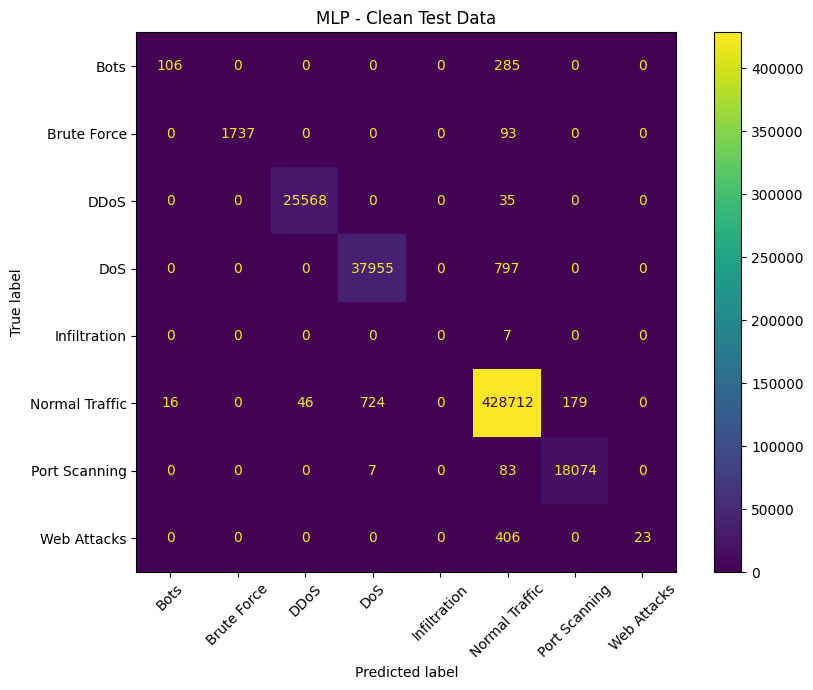

In [53]:
def predict_mlp(model, data_loader):
    """Return predictions and labels for a PyTorch model/data loader."""
    model.eval()
    predictions = []
    labels = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(DEVICE)
            outputs = model(batch_X)
            batch_preds = torch.argmax(outputs, dim=1).cpu().numpy()
            predictions.extend(batch_preds)
            labels.extend(batch_y.numpy())

    return np.array(labels), np.array(predictions)


mlp_clean_labels, mlp_clean_preds = predict_mlp(mlp, test_loader)
add_result("MLP", "clean", mlp_clean_labels, mlp_clean_preds)
show_classification_summary("MLP", "clean", mlp_clean_labels, mlp_clean_preds)
plot_confusion(mlp_clean_labels, mlp_clean_preds, "MLP - Clean Test Data")

## 10. Generate FGSM and PGD Adversarial Examples

FGSM and PGD perturb the scaled tabular feature vectors in the direction that increases the neural network's loss.

Important limitation: these attacks show model sensitivity in feature space, but they do not guarantee that every perturbed vector corresponds to a physically valid network flow. We should mention this limitation in the final report.

In [ ]:
feature_min = torch.tensor(X_train_scaled.min(axis=0), dtype=torch.float32, device=DEVICE)
feature_max = torch.tensor(X_train_scaled.max(axis=0), dtype=torch.float32, device=DEVICE)


def fgsm_attack(model, X_batch, y_batch, epsilon):
    """Fast Gradient Sign Method attack on scaled feature vectors."""
    model.eval()
    X_adv = X_batch.clone().detach().to(DEVICE)
    y_batch = y_batch.to(DEVICE)
    X_adv.requires_grad = True

    outputs = model(X_adv)
    loss = criterion(outputs, y_batch)

    model.zero_grad()
    loss.backward()

    perturbation = epsilon * X_adv.grad.sign()
    X_adv = X_adv + perturbation
    X_adv = torch.max(torch.min(X_adv, feature_max), feature_min)
    return X_adv.detach()


def pgd_attack(model, X_batch, y_batch, epsilon, alpha, steps):
    """Projected Gradient Descent attack on scaled feature vectors."""
    model.eval()
    X_original = X_batch.clone().detach().to(DEVICE)
    y_batch = y_batch.to(DEVICE)
    X_adv = X_original.clone().detach()

    for _ in range(steps):
        X_adv.requires_grad = True
        outputs = model(X_adv)
        loss = criterion(outputs, y_batch)

        model.zero_grad()
        loss.backward()

        X_adv = X_adv + alpha * X_adv.grad.sign()
        perturbation = torch.clamp(X_adv - X_original, min=-epsilon, max=epsilon)
        X_adv = X_original + perturbation
        X_adv = torch.max(torch.min(X_adv, feature_max), feature_min).detach()

    return X_adv


def generate_adversarial_dataset(model, data_loader, attack_name, **attack_kwargs):
    """Generate adversarial examples and evaluate the MLP on them."""
    model.eval()
    adv_batches = []
    label_batches = []
    predictions = []
    labels = []

    for batch_X, batch_y in data_loader:
        batch_X = batch_X.to(DEVICE)
        batch_y = batch_y.to(DEVICE)

        if attack_name == "FGSM":
            adv_X = fgsm_attack(model, batch_X, batch_y, **attack_kwargs)
        elif attack_name == "PGD":
            adv_X = pgd_attack(model, batch_X, batch_y, **attack_kwargs)
        else:
            raise ValueError(f"Unknown attack: {attack_name}")

        adv_batches.append(adv_X.cpu())
        label_batches.append(batch_y.cpu())

        with torch.no_grad():
            outputs = model(adv_X)
            batch_preds = torch.argmax(outputs, dim=1).cpu().numpy()

        predictions.extend(batch_preds)
        labels.extend(batch_y.cpu().numpy())

    X_adv = torch.cat(adv_batches).numpy()
    y_adv = torch.cat(label_batches).numpy()
    return X_adv, y_adv, np.array(labels), np.array(predictions)

MLP - FGSM epsilon=0.05
accuracy: 0.9268
weighted_f1: 0.9257
macro_f1: 0.4685
balanced_accuracy: 0.4835

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.35      0.71      0.47      1830
          DDoS       0.84      0.74      0.79     25603
           DoS       0.90      0.91      0.90     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.95      0.96      0.96    429677
 Port Scanning       0.56      0.49      0.53     18164
   Web Attacks       1.00      0.05      0.10       429

      accuracy                           0.93    514853
     macro avg       0.58      0.48      0.47    514853
  weighted avg       0.93      0.93      0.93    514853



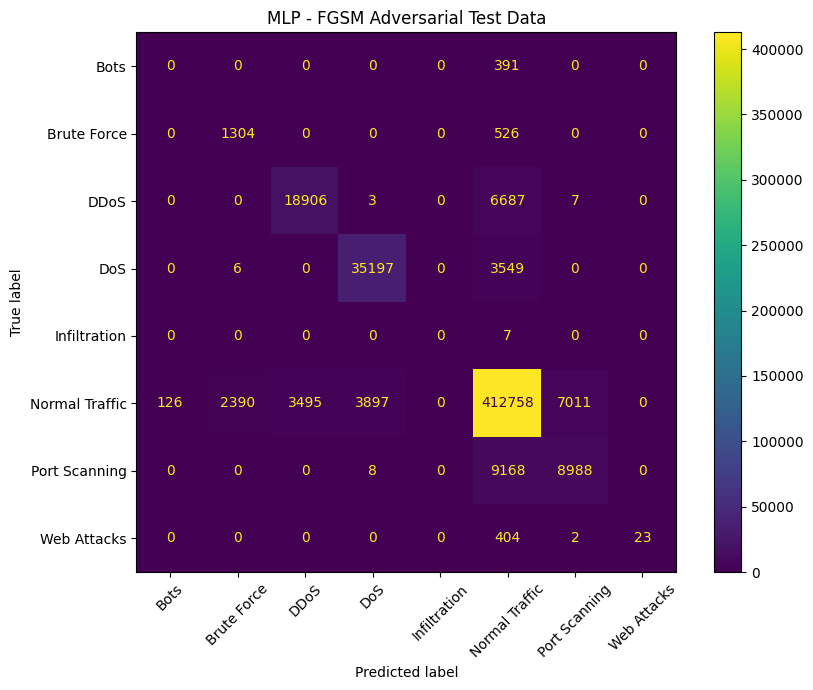

X_test_fgsm shape: (514853, 69)


In [92]:
X_test_fgsm, y_test_fgsm, fgsm_labels, fgsm_preds = generate_adversarial_dataset(
    mlp,
    test_loader,
    attack_name="FGSM",
    epsilon=FGSM_EPSILON,
)

add_result("MLP", "FGSM", fgsm_labels, fgsm_preds, notes=f"epsilon={FGSM_EPSILON}")
show_classification_summary("MLP", f"FGSM epsilon={FGSM_EPSILON}", fgsm_labels, fgsm_preds)
plot_confusion(fgsm_labels, fgsm_preds, "MLP - FGSM Adversarial Test Data")

print("X_test_fgsm shape:", X_test_fgsm.shape)

MLP - PGD epsilon=0.05
accuracy: 0.9171
weighted_f1: 0.9165
macro_f1: 0.4462
balanced_accuracy: 0.4583

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.28      0.57      0.38      1830
          DDoS       0.81      0.69      0.74     25603
           DoS       0.87      0.91      0.89     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.95      0.95      0.95    429677
 Port Scanning       0.52      0.49      0.51     18164
   Web Attacks       1.00      0.05      0.10       429

      accuracy                           0.92    514853
     macro avg       0.55      0.46      0.45    514853
  weighted avg       0.92      0.92      0.92    514853



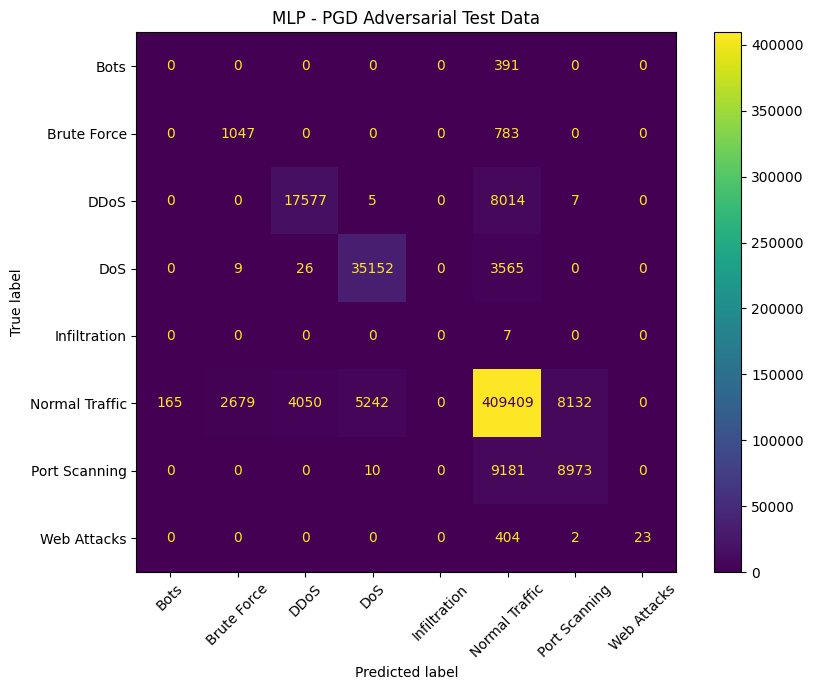

X_test_pgd shape: (514853, 69)


In [56]:
X_test_pgd, y_test_pgd, pgd_labels, pgd_preds = generate_adversarial_dataset(
    mlp,
    test_loader,
    attack_name="PGD",
    epsilon=PGD_EPSILON,
    alpha=PGD_ALPHA,
    steps=PGD_STEPS,
)

add_result(
    "MLP",
    "PGD",
    pgd_labels,
    pgd_preds,
    notes=f"epsilon={PGD_EPSILON}, alpha={PGD_ALPHA}, steps={PGD_STEPS}",
)
show_classification_summary("MLP", f"PGD epsilon={PGD_EPSILON}", pgd_labels, pgd_preds)
plot_confusion(pgd_labels, pgd_preds, "MLP - PGD Adversarial Test Data")

print("X_test_pgd shape:", X_test_pgd.shape)

In [58]:
## 10.5 Epsilon Sweep

#To evaluate the impact of perturbation strength on model performance, FGSM and PGD attacks are tested across multiple epsilon values. This allows comparison of performance degradation under progressively stronger adversarial perturbations.

# ==============================
# 10.5 Epsilon Sweep
# ==============================

sweep_results = []

# Start small to test runtime. Expand later if needed.
EPSILON_SWEEP = [0.001, 0.005, 0.01, 0.03, 0.05, 0.1]

for eps in EPSILON_SWEEP:
    print(f"\n==============================")
    print(f"Running epsilon sweep for eps = {eps}")
    print(f"==============================")

    # ---------- FGSM ----------
    X_fgsm_eps, y_fgsm_eps, fgsm_labels_eps, fgsm_preds_eps = generate_adversarial_dataset(
        mlp,
        test_loader,
        attack_name="FGSM",
        epsilon=eps
    )

    fgsm_acc = accuracy_score(fgsm_labels_eps, fgsm_preds_eps)
    fgsm_f1 = f1_score(fgsm_labels_eps, fgsm_preds_eps, average="weighted")

    fgsm_macro_f1 = f1_score(
    fgsm_labels_eps,
    fgsm_preds_eps,
    average="macro"
    )

    sweep_results.append({
        "model": "MLP",
        "attack": "FGSM",
        "epsilon": eps,
        "alpha": None,
        "steps": 1,
        "accuracy": fgsm_acc,
        "weighted_f1": fgsm_f1,
        "macro_f1": fgsm_macro_f1,
        "notes": f"epsilon={eps}"
    })

    # ---------- PGD ----------
    X_pgd_eps, y_pgd_eps, pgd_labels_eps, pgd_preds_eps = generate_adversarial_dataset(
        mlp,
        test_loader,
        attack_name="PGD",
        epsilon=eps,
        alpha=eps / 5,
        steps=PGD_STEPS
    )

    pgd_acc = accuracy_score(pgd_labels_eps, pgd_preds_eps)
    pgd_f1 = f1_score(pgd_labels_eps, pgd_preds_eps, average="weighted")

    pgd_macro_f1 = f1_score(
    pgd_labels_eps,
    pgd_preds_eps,
    average="macro"
    )

    sweep_results.append({
        "model": "MLP",
        "attack": "PGD",
        "epsilon": eps,
        "alpha": eps / 5,
        "steps": PGD_STEPS,
        "accuracy": pgd_acc,
        "macro_f1": pgd_macro_f1,
        "weighted_f1": pgd_f1,
        "notes": f"epsilon={eps}, alpha={eps / 5}, steps={PGD_STEPS}"
    })

# Convert sweep results to DataFrame
epsilon_sweep_df = pd.DataFrame(sweep_results)

print("\nEpsilon Sweep Results:")
display(epsilon_sweep_df)

# Save results
epsilon_sweep_df.to_csv("epsilon_sweep_results.csv", index=False)
print("Saved epsilon_sweep_results.csv")


Running epsilon sweep for eps = 0.001

Running epsilon sweep for eps = 0.005

Running epsilon sweep for eps = 0.01

Running epsilon sweep for eps = 0.03

Running epsilon sweep for eps = 0.05

Running epsilon sweep for eps = 0.1

Epsilon Sweep Results:


,model,attack,epsilon,alpha,steps,accuracy,weighted_f1,macro_f1,notes
0,MLP,FGSM,0.001,NaN,1,0.994552,0.994035,0.681875,epsilon=0.001
1,MLP,PGD,0.001,0.0002,10,0.994552,0.994035,0.681875,"epsilon=0.001, alpha=0.0002, steps=10"
2,MLP,FGSM,0.005,NaN,1,0.993858,0.993324,0.674968,epsilon=0.005
3,MLP,PGD,0.005,0.0010,10,0.993853,0.993318,0.674923,"epsilon=0.005, alpha=0.001, steps=10"
4,MLP,FGSM,0.010,NaN,1,0.991514,0.990943,0.662021,epsilon=0.01
5,MLP,PGD,0.010,0.0020,10,0.991388,0.990816,0.661784,"epsilon=0.01, alpha=0.002, steps=10"
6,MLP,FGSM,0.030,NaN,1,0.949040,0.948002,0.510897,epsilon=0.03
7,MLP,PGD,0.030,0.0060,10,0.941583,0.940244,0.497432,"epsilon=0.03, alpha=0.006, steps=10"
8,MLP,FGSM,0.050,NaN,1,0.926820,0.925703,0.468454,epsilon=0.05
9,MLP,PGD,0.050,0.0100,10,0.917118,0.916488,0.446163,"epsilon=0.05, alpha=0.01, steps=10"


Saved epsilon_sweep_results.csv


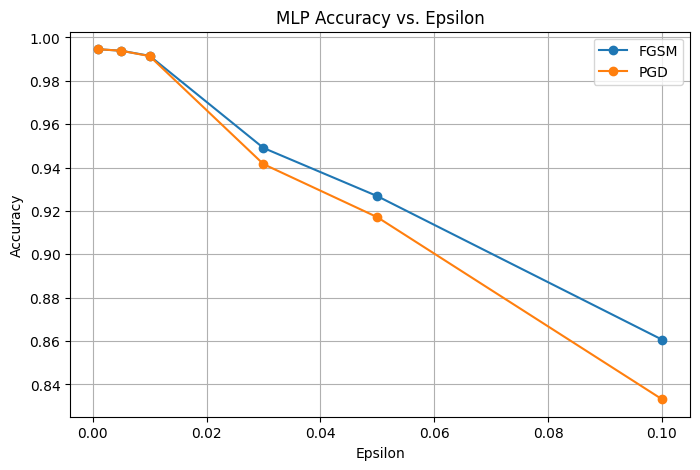

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

for attack in epsilon_sweep_df["attack"].unique():
    subset = epsilon_sweep_df[epsilon_sweep_df["attack"] == attack]
    plt.plot(subset["epsilon"], subset["accuracy"], marker="o", label=attack)

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy vs. Epsilon")
plt.legend()
plt.grid(True)
plt.show()

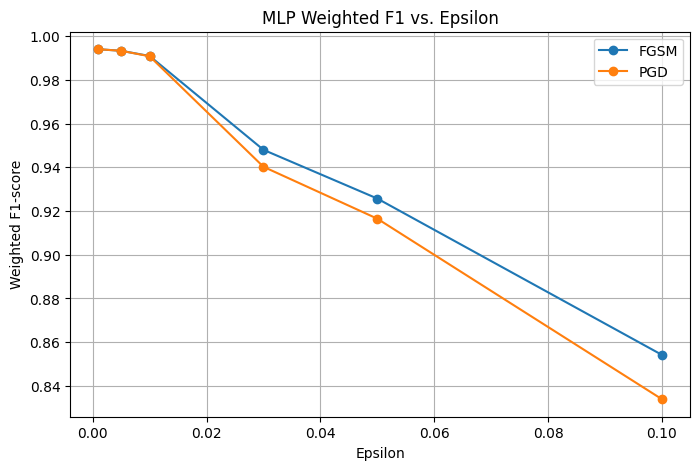

In [ ]:
plt.figure(figsize=(8, 5))

for attack in epsilon_sweep_df["attack"].unique():
    subset = epsilon_sweep_df[epsilon_sweep_df["attack"] == attack]
    plt.plot(subset["epsilon"], subset["weighted_f1"], marker="o", label=attack)

plt.xlabel("Epsilon")
plt.ylabel("Weighted F1-score")
plt.title("MLP Weighted F1 vs. Epsilon")
plt.legend()
plt.grid(True)
plt.show()

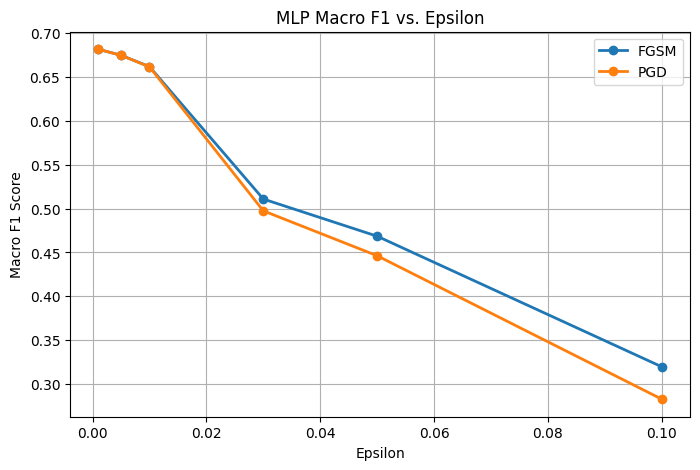

In [ ]:
plt.figure(figsize=(8, 5))

for attack in epsilon_sweep_df["attack"].unique():
    subset = epsilon_sweep_df[epsilon_sweep_df["attack"] == attack]
    plt.plot(
        subset["epsilon"],
        subset["macro_f1"],
        marker="o",
        linewidth=2,
        label=attack
    )

plt.xlabel("Epsilon")
plt.ylabel("Macro F1 Score")
plt.title("MLP Macro F1 vs. Epsilon")
plt.legend()
plt.grid(True)

plt.savefig("macro_f1_vs_epsilon.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Test Transferability to Classical Models

Here we reuse the FGSM and PGD examples generated against the MLP and evaluate the classical models on those same perturbed feature vectors.

If Logistic Regression or Random Forest performance drops, that suggests the adversarial examples are at least partially transferable across model types.

Logistic Regression - FGSM
accuracy: 0.9075
weighted_f1: 0.8902
macro_f1: 0.3186
balanced_accuracy: 0.2938

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.06      0.03      0.04      1830
          DDoS       0.96      0.44      0.60     25603
           DoS       0.88      0.85      0.86     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.92      0.98      0.95    429677
 Port Scanning       0.01      0.00      0.01     18164
   Web Attacks       0.78      0.04      0.08       429

      accuracy                           0.91    514853
     macro avg       0.45      0.29      0.32    514853
  weighted avg       0.89      0.91      0.89    514853



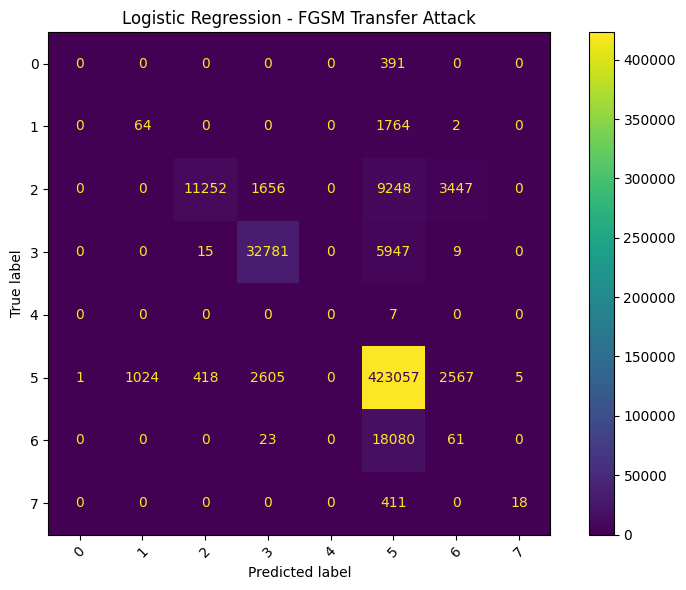

Logistic Regression - PGD
accuracy: 0.8999
weighted_f1: 0.8867
macro_f1: 0.3200
balanced_accuracy: 0.2953

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.08      0.02      0.03      1830
          DDoS       0.95      0.47      0.63     25603
           DoS       0.87      0.84      0.86     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.92      0.97      0.95    429677
 Port Scanning       0.02      0.01      0.02     18164
   Web Attacks       0.75      0.04      0.08       429

      accuracy                           0.90    514853
     macro avg       0.45      0.30      0.32    514853
  weighted avg       0.88      0.90      0.89    514853



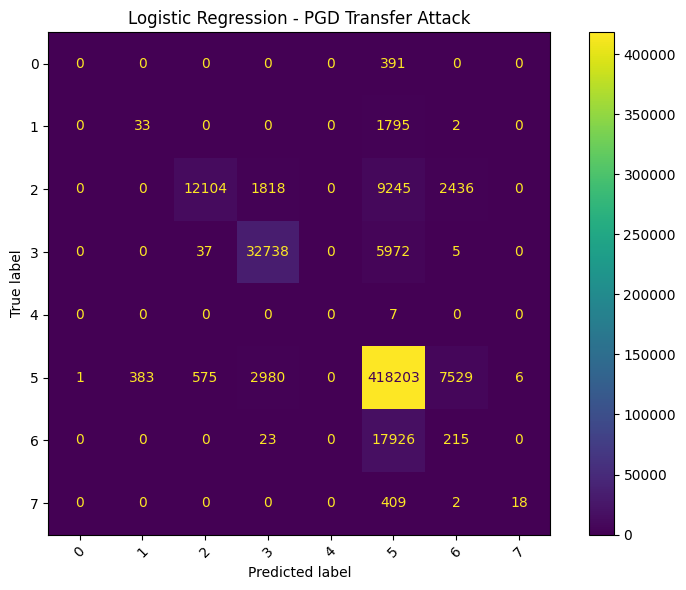

Random Forest - FGSM
accuracy: 0.9170
weighted_f1: 0.8932
macro_f1: 0.3072
balanced_accuracy: 0.2827

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.00      0.00      0.00      1830
          DDoS       1.00      0.49      0.66     25603
           DoS       0.93      0.77      0.85     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.91      1.00      0.95    429677
 Port Scanning       0.70      0.00      0.00     18164
   Web Attacks       0.00      0.00      0.00       429

      accuracy                           0.92    514853
     macro avg       0.44      0.28      0.31    514853
  weighted avg       0.91      0.92      0.89    514853



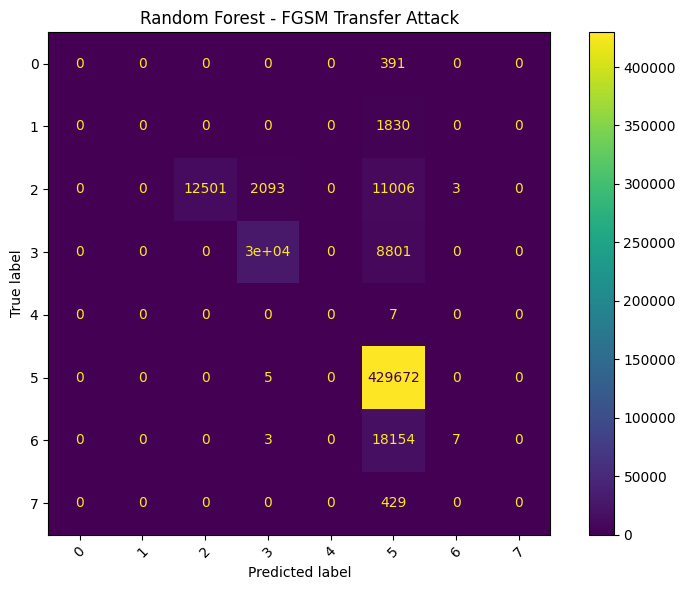

Random Forest - PGD
accuracy: 0.9137
weighted_f1: 0.8897
macro_f1: 0.3038
balanced_accuracy: 0.2776

Classification report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00       391
   Brute Force       0.00      0.00      0.00      1830
          DDoS       1.00      0.50      0.66     25603
           DoS       0.92      0.72      0.81     38752
  Infiltration       0.00      0.00      0.00         7
Normal Traffic       0.91      1.00      0.95    429677
 Port Scanning       0.62      0.00      0.00     18164
   Web Attacks       0.00      0.00      0.00       429

      accuracy                           0.91    514853
     macro avg       0.43      0.28      0.30    514853
  weighted avg       0.90      0.91      0.89    514853



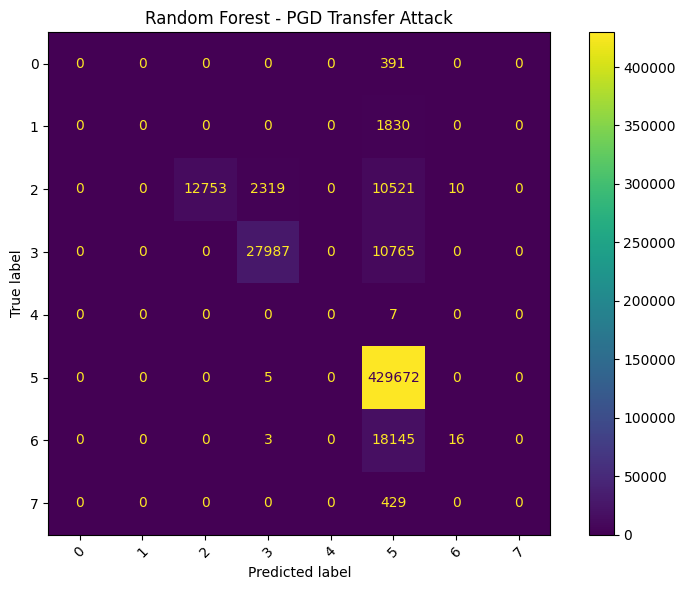

In [60]:
adversarial_sets = {
    "FGSM": (X_test_fgsm, y_test_fgsm),
    "PGD": (X_test_pgd, y_test_pgd),
}

for model_name, model in sklearn_models.items():
    for attack_name, (X_adv, y_adv) in adversarial_sets.items():
        adv_preds = model.predict(X_adv)
        add_result(model_name, attack_name, y_adv, adv_preds, notes="transfer attack generated from MLP")
        show_classification_summary(model_name, attack_name, y_adv, adv_preds)
        fig, ax = plt.subplots(figsize=(8,6))

        ConfusionMatrixDisplay.from_predictions(
            y_adv,
            adv_preds,
            ax=ax,
            xticks_rotation=45
        )

        ax.set_title(
            f"{model_name} - {attack_name} Transfer Attack"
        )

        plt.tight_layout()
        plt.show()

## 12. Results Summary

This table is the main output of the experiment. For the final report, the most important comparison is clean performance versus adversarial performance.

,model,condition,accuracy,weighted_f1,macro_f1,balanced_accuracy,notes
0,Logistic Regression,clean,0.9869,0.9860,0.6082,0.5868,
1,Random Forest,clean,0.9980,0.9979,0.8357,0.7994,
2,MLP,clean,0.9948,0.9943,0.6821,0.6556,
3,MLP,PGD,0.9171,0.9165,0.4462,0.4583,"epsilon=0.05, alpha=0.01, steps=10"
4,Logistic Regression,FGSM,0.9075,0.8902,0.3186,0.2938,transfer attack generated from MLP
5,Logistic Regression,PGD,0.8999,0.8867,0.3200,0.2953,transfer attack generated from MLP
6,Random Forest,FGSM,0.9170,0.8932,0.3072,0.2827,transfer attack generated from MLP
7,Random Forest,PGD,0.9137,0.8897,0.3038,0.2776,transfer attack generated from MLP
8,Adv-Trained MLP,Clean,0.9927,0.9919,0.6151,0.5951,FGSM adversarial training
9,Adv-Trained MLP,FGSM,0.9772,0.9773,0.5910,0.5878,"FGSM adversarial training, epsilon=0.05"


Saved results to outputs\results_summary.csv
Saved results to outputs\results_summary.json


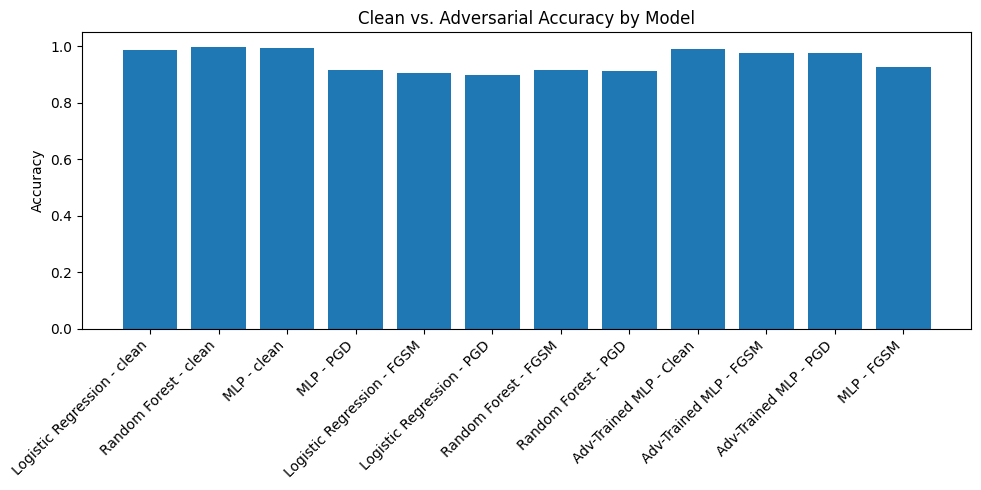

In [103]:
results_df = pd.DataFrame(results)
metric_cols = ["accuracy", "weighted_f1", "macro_f1", "balanced_accuracy"]
results_display = results_df.copy()
for col in metric_cols:
    results_display[col] = results_display[col].map(lambda value: f"{value:.4f}")

display(results_display)

results_df.to_csv(OUTPUT_DIR / "results_summary.csv", index=False)
with open(OUTPUT_DIR / "results_summary.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Saved results to {OUTPUT_DIR / 'results_summary.csv'}")
print(f"Saved results to {OUTPUT_DIR / 'results_summary.json'}")

plt.figure(figsize=(10, 5))
plot_df = results_df.copy()
plot_df["label"] = plot_df["model"] + " - " + plot_df["condition"]
plt.bar(plot_df["label"], plot_df["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Clean vs. Adversarial Accuracy by Model")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [104]:
results_df["condition"] = results_df["condition"].replace({
    "Clean": "clean"
})

In [105]:
accuracy_table = results_df.pivot_table(
    index="model",
    columns="condition",
    values="accuracy"
)

accuracy_table

condition,FGSM,PGD,clean
model,,,
Adv-Trained MLP,0.977215,0.975616,0.992724
Logistic Regression,0.907508,0.899890,0.986942
MLP,0.926820,0.917118,0.994799
Random Forest,0.917021,0.913713,0.997990


In [106]:
macro_table = results_df.pivot_table(
    index="model",
    columns="condition",
    values="macro_f1"
)

macro_table

condition,FGSM,PGD,clean
model,,,
Adv-Trained MLP,0.590999,0.588478,0.615051
Logistic Regression,0.318626,0.320044,0.608156
MLP,0.468454,0.446163,0.682143
Random Forest,0.307226,0.303811,0.835716


In [107]:
weighted_table = results_df.pivot_table(
    index="model",
    columns="condition",
    values="weighted_f1"
)

weighted_table

condition,FGSM,PGD,clean
model,,,
Adv-Trained MLP,0.977268,0.975671,0.991901
Logistic Regression,0.890176,0.886668,0.986016
MLP,0.925703,0.916488,0.994284
Random Forest,0.893227,0.889723,0.997889


In [108]:
accuracy_drop = accuracy_table.copy()

for attack in ["FGSM", "PGD"]:

    accuracy_drop[attack] = (
        accuracy_table["clean"]
        - accuracy_table[attack]
    )

accuracy_drop = accuracy_drop[
    ["FGSM","PGD"]
]

accuracy_drop

condition,FGSM,PGD
model,,
Adv-Trained MLP,0.015509,0.017108
Logistic Regression,0.079434,0.087052
MLP,0.067979,0.077680
Random Forest,0.080969,0.084276


In [109]:
macro_drop = macro_table.copy()

for attack in ["FGSM", "PGD"]:

    macro_drop[attack] = (
        macro_table["clean"]
        - macro_table[attack]
    )

macro_drop = macro_drop[
    ["FGSM","PGD"]
]

macro_drop

condition,FGSM,PGD
model,,
Adv-Trained MLP,0.024052,0.026573
Logistic Regression,0.289530,0.288112
MLP,0.213689,0.235980
Random Forest,0.528490,0.531905


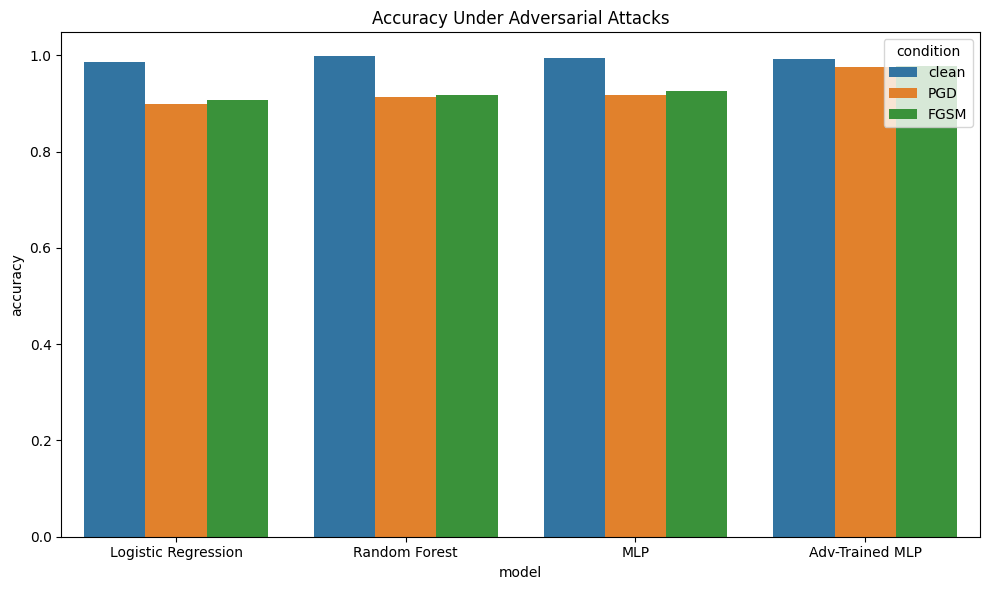

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="model",
    y="accuracy",
    hue="condition"
)

plt.title(
    "Accuracy Under Adversarial Attacks"
)

plt.tight_layout()
plt.show()

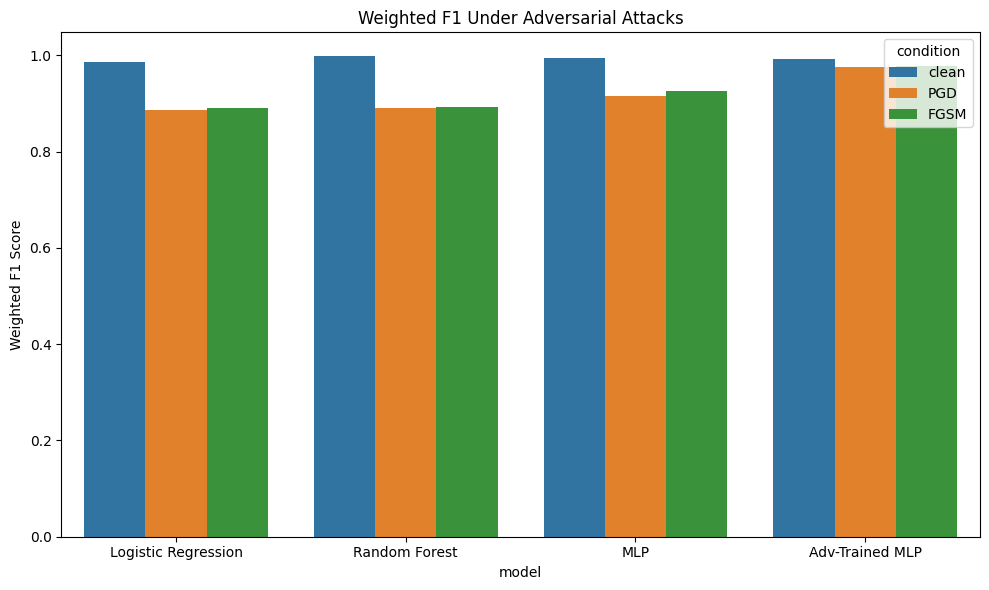

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="model",
    y="weighted_f1",
    hue="condition"
)

plt.title("Weighted F1 Under Adversarial Attacks")
plt.ylabel("Weighted F1 Score")

plt.tight_layout()
plt.show()

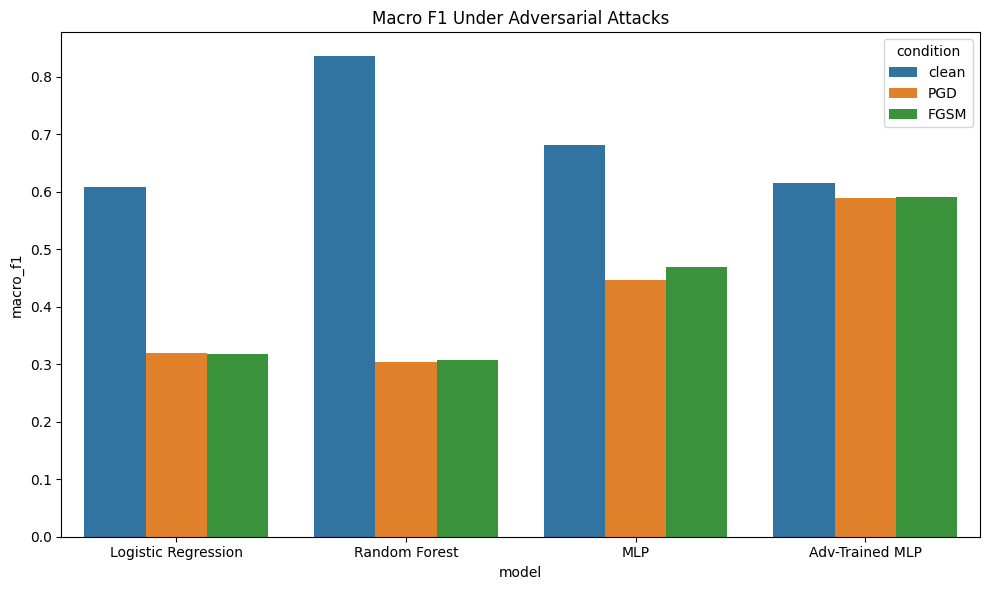

In [112]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="model",
    y="macro_f1",
    hue="condition"
)

plt.title(
    "Macro F1 Under Adversarial Attacks"
)

plt.tight_layout()
plt.show()

## 13. Save Reproducibility Artifacts

This section saves the scaler, imputation values, label encoder, model files, feature list, and experiment configuration. These are necessary if we want to reload the trained models later without rerunning the full notebook.

In [73]:
# Scikit-learn and preprocessing artifacts
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
joblib.dump(label_encoder, MODEL_DIR / "label_encoder.joblib")
joblib.dump(train_medians, MODEL_DIR / "train_medians.joblib")
joblib.dump(log_reg, MODEL_DIR / "logistic_regression_model.joblib")
joblib.dump(random_forest, MODEL_DIR / "random_forest_model.joblib")

if CLIP_EXTREME_VALUES:
    joblib.dump(lower_bounds, MODEL_DIR / "clip_lower_bounds.joblib")
    joblib.dump(upper_bounds, MODEL_DIR / "clip_upper_bounds.joblib")

# PyTorch model state
mlp_artifact = {
    "state_dict": mlp.state_dict(),
    "input_dim": X_train_scaled.shape[1],
    "num_classes": len(class_names),
    "class_names": class_names,
    "dropout": DROPOUT,
}
torch.save(mlp_artifact, MODEL_DIR / "mlp_model.pth")

# Feature/config metadata
with open(OUTPUT_DIR / "feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)

experiment_config = {
    "random_state": RANDOM_STATE,
    "data_metadata": data_metadata,
    "label_mode": LABEL_MODE,
    "test_size": TEST_SIZE,
    "batch_size": BATCH_SIZE,
    "mlp_epochs": MLP_EPOCHS,
    "mlp_learning_rate": MLP_LEARNING_RATE,
    "dropout": DROPOUT,
    "sklearn_train_limit": SKLEARN_TRAIN_LIMIT,
    "fgsm_epsilon": FGSM_EPSILON,
    "pgd_epsilon": PGD_EPSILON,
    "pgd_alpha": PGD_ALPHA,
    "pgd_steps": PGD_STEPS,
    "clip_extreme_values": CLIP_EXTREME_VALUES,
    "clip_lower_quantile": CLIP_LOWER_QUANTILE,
    "clip_upper_quantile": CLIP_UPPER_QUANTILE,
    "max_missing_ratio": MAX_MISSING_RATIO,
    "class_names": class_names,
}
with open(OUTPUT_DIR / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)

print(f"Saved artifacts under: {OUTPUT_DIR.resolve()}")

Saved artifacts under: C:\Users\amogh\429\CSC429Project\Intrusion-Detection-CICIDS2017\outputs


## 14. Current Project Status and Next Steps

At this point, the project has a working experimental backbone:

- Local raw-data loading.
- Clean-data intrusion detection baselines.
- A PyTorch neural-network IDS model.
- FGSM and PGD adversarial evaluation.
- Transferability testing against Logistic Regression and Random Forest.
- Saved results and model artifacts.

Recommended next steps after this cleanup:

1. Add an epsilon sweep to show how attack strength changes accuracy/F1.
2. Add stronger minority-class analysis, especially macro F1 and recall per attack class.
3. Add at least one defense, such as adversarial training.
4. Move reusable functions into `src/` after the notebook is stable.

In [74]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [75]:
# ==============================
# Compatibility Fix for Local Notebook Variable Names
# ==============================

# This notebook uses X_train_scaled / X_test_scaled instead of X_train / X_test
X_train = X_train_scaled
X_test = X_test_scaled

# This notebook uses label_encoder / class_names instead of le
le = label_encoder

input_dim = X_train.shape[1]
num_classes = len(class_names)

print("input_dim =", input_dim)
print("num_classes =", num_classes)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

input_dim = 69
num_classes = 8
X_train shape: (2059411, 69)
X_test shape: (514853, 69)


In [ ]:
## Adversarial Training

##Train a second MLP using FGSM adversarial examples generated during training. This acts as a simple defense baseline.

In [76]:
input_dim = X_train.shape[1]
num_classes = len(le.classes_)

print("input_dim =", input_dim)
print("num_classes =", num_classes)

input_dim = 69
num_classes = 8


In [77]:
LEARNING_RATE = 0.001

In [78]:
ADV_EPOCHS = 3
ADV_EPSILON = 0.05

adv_mlp = MLP(input_dim, num_classes).to(device)

adv_criterion = nn.CrossEntropyLoss()
adv_optimizer = torch.optim.Adam(adv_mlp.parameters(), lr=LEARNING_RATE)

print("adv_mlp created successfully")

adv_mlp created successfully


In [79]:
# ==============================
# Train MLP with FGSM Adversarial Training
# ==============================

for epoch in range(ADV_EPOCHS):
    adv_mlp.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Generate FGSM adversarial examples using current adv_mlp
        batch_X_adv = batch_X.clone().detach()
        batch_X_adv.requires_grad = True

        outputs_adv_gen = adv_mlp(batch_X_adv)
        loss_adv_gen = adv_criterion(outputs_adv_gen, batch_y)

        adv_mlp.zero_grad()
        loss_adv_gen.backward()

        perturbation = ADV_EPSILON * batch_X_adv.grad.sign()
        batch_X_adv = (batch_X_adv + perturbation).detach()

        # Combine clean + adversarial samples
        combined_X = torch.cat([batch_X, batch_X_adv], dim=0)
        combined_y = torch.cat([batch_y, batch_y], dim=0)

        # Train on combined batch
        adv_optimizer.zero_grad()
        outputs = adv_mlp(combined_X)
        loss = adv_criterion(outputs, combined_y)
        loss.backward()
        adv_optimizer.step()

        total_loss += loss.item()

    print(f"Adv Training Epoch {epoch+1}/{ADV_EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

Adv Training Epoch 1/3, Loss: 0.1088
Adv Training Epoch 2/3, Loss: 0.0534
Adv Training Epoch 3/3, Loss: 0.0448


In [80]:
# ==============================
# Evaluate Adversarially Trained MLP on Clean Test Data
# ==============================

adv_mlp.eval()
adv_clean_preds = []
adv_clean_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = adv_mlp(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        adv_clean_preds.extend(preds)
        adv_clean_labels.extend(batch_y.numpy())

adv_clean_acc = accuracy_score(adv_clean_labels, adv_clean_preds)
adv_clean_f1 = f1_score(adv_clean_labels, adv_clean_preds, average="weighted")

adv_clean_macro_f1 = f1_score(
    adv_clean_labels,
    adv_clean_preds,
    average="macro"
)

print("Adversarially Trained MLP Clean Accuracy:", adv_clean_acc)
print("Adversarially Trained MLP Clean Weighted F1:", adv_clean_f1)
print("Adversarially Trained MLP Clean Macro F1:", adv_clean_macro_f1)

add_result(
    "Adv-Trained MLP",
    "Clean",
    adv_clean_labels,
    adv_clean_preds,
    notes="FGSM adversarial training"
)

Adversarially Trained MLP Clean Accuracy: 0.9927241367924436
Adversarially Trained MLP Clean Weighted F1: 0.9919006069827381
Adversarially Trained MLP Clean Macro F1: 0.615050931671789


{'model': 'Adv-Trained MLP',
 'condition': 'Clean',
 'accuracy': 0.9927241367924436,
 'weighted_f1': 0.9919006069827381,
 'macro_f1': 0.615050931671789,
 'balanced_accuracy': 0.5951065230610117,
 'notes': 'FGSM adversarial training'}

In [81]:
# ==============================
# Evaluate Adversarially Trained MLP Under FGSM and PGD
# ==============================

# FGSM evaluation
X_advtrain_fgsm, y_advtrain_fgsm, advtrain_fgsm_labels, advtrain_fgsm_preds = generate_adversarial_dataset(
    adv_mlp,
    test_loader,
    attack_name="FGSM",
    epsilon=FGSM_EPSILON
)

advtrain_fgsm_acc = accuracy_score(advtrain_fgsm_labels, advtrain_fgsm_preds)
advtrain_fgsm_f1 = f1_score(advtrain_fgsm_labels, advtrain_fgsm_preds, average="weighted")

advtrain_fgsm_macro_f1 = f1_score(
    advtrain_fgsm_labels,
    advtrain_fgsm_preds,
    average="macro"
)

print("Adv-Trained MLP FGSM Accuracy:", advtrain_fgsm_acc)
print("Adv-Trained MLP FGSM Weighted F1:", advtrain_fgsm_f1)
print("Adv-Trained MLP FGSM Macro F1:", advtrain_fgsm_macro_f1)

add_result(
    "Adv-Trained MLP",
    "FGSM",
    advtrain_fgsm_labels,
    advtrain_fgsm_preds,
    notes=f"FGSM adversarial training, epsilon={FGSM_EPSILON}"
)

# PGD evaluation
X_advtrain_pgd, y_advtrain_pgd, advtrain_pgd_labels, advtrain_pgd_preds = generate_adversarial_dataset(
    adv_mlp,
    test_loader,
    attack_name="PGD",
    epsilon=PGD_EPSILON,
    alpha=PGD_ALPHA,
    steps=PGD_STEPS
)

advtrain_pgd_acc = accuracy_score(advtrain_pgd_labels, advtrain_pgd_preds)
advtrain_pgd_f1 = f1_score(advtrain_pgd_labels, advtrain_pgd_preds, average="weighted")
advtrain_pgd_macro_f1 = f1_score(
    advtrain_pgd_labels,
    advtrain_pgd_preds,
    average="macro"
)

print("Adv-Trained MLP PGD Accuracy:", advtrain_pgd_acc)
print("Adv-Trained MLP PGD Weighted F1:", advtrain_pgd_f1)
print("Adv-Trained MLP PGD Macro F1:", advtrain_pgd_macro_f1)

add_result(
    "Adv-Trained MLP",
    "PGD",
    advtrain_pgd_labels,
    advtrain_pgd_preds,
    notes=f"FGSM adversarial training, evaluated on PGD epsilon={PGD_EPSILON}, alpha={PGD_ALPHA}, steps={PGD_STEPS}"
)

Adv-Trained MLP FGSM Accuracy: 0.9772148555024444
Adv-Trained MLP FGSM Weighted F1: 0.9772676215555016
Adv-Trained MLP FGSM Macro F1: 0.5909994130309871
Adv-Trained MLP PGD Accuracy: 0.9756163409749967
Adv-Trained MLP PGD Weighted F1: 0.9756708216591486
Adv-Trained MLP PGD Macro F1: 0.5884780705460905


{'model': 'Adv-Trained MLP',
 'condition': 'PGD',
 'accuracy': 0.9756163409749967,
 'weighted_f1': 0.9756708216591486,
 'macro_f1': 0.5884780705460905,
 'balanced_accuracy': 0.5834173105099401,
 'notes': 'FGSM adversarial training, evaluated on PGD epsilon=0.05, alpha=0.01, steps=10'}

In [82]:
[k for k in globals().keys() if "acc" in k.lower() or "f1" in k.lower()]

['accuracy_score',
 'balanced_accuracy_score',
 'f1_score',
 'fgsm_acc',
 'fgsm_f1',
 'fgsm_macro_f1',
 'pgd_acc',
 'pgd_f1',
 'pgd_macro_f1',
 'adv_clean_acc',
 'adv_clean_f1',
 'adv_clean_macro_f1',
 'advtrain_fgsm_acc',
 'advtrain_fgsm_f1',
 'advtrain_fgsm_macro_f1',
 'advtrain_pgd_acc',
 'advtrain_pgd_f1',
 'advtrain_pgd_macro_f1',
 'clean_acc',
 'clean_f1',
 'clean_macro_f1',
 'acc_df',
 'f1_df',
 'accuracy_table',
 'accuracy_drop']

In [83]:
# Recompute original MLP clean metrics
mlp.eval()
orig_clean_preds = []
orig_clean_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        outputs = mlp(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        orig_clean_preds.extend(preds)
        orig_clean_labels.extend(batch_y.numpy())

clean_acc = accuracy_score(orig_clean_labels, orig_clean_preds)
clean_f1 = f1_score(orig_clean_labels, orig_clean_preds, average="weighted")
clean_macro_f1 = f1_score(
    orig_clean_labels,
    orig_clean_preds,
    average="macro"
)

print("Original MLP Clean Accuracy:", clean_acc)
print("Original MLP Clean F1:", clean_f1)
print("Original MLP Clean Macro F1:", clean_macro_f1)

Original MLP Clean Accuracy: 0.9947985153043685
Original MLP Clean F1: 0.9942835461833891
Original MLP Clean Macro F1: 0.6821434238439152


In [84]:
adv_training_comparison = pd.DataFrame([
    {
        "Model": "Original MLP",
        "Clean Accuracy": clean_acc,
        "FGSM Accuracy": fgsm_acc,
        "PGD Accuracy": pgd_acc,
        "Clean F1": clean_f1,
        "FGSM F1": fgsm_f1,
        "PGD F1": pgd_f1
    },
    {
        "Model": "Adv-Trained MLP",
        "Clean Accuracy": adv_clean_acc,
        "FGSM Accuracy": advtrain_fgsm_acc,
        "PGD Accuracy": advtrain_pgd_acc,
        "Clean F1": adv_clean_f1,
        "FGSM F1": advtrain_fgsm_f1,
        "PGD F1": advtrain_pgd_f1
    }
])

display(adv_training_comparison)

adv_training_comparison.to_csv("adversarial_training_comparison.csv", index=False)
print("Saved adversarial_training_comparison.csv")

,Model,Clean Accuracy,FGSM Accuracy,PGD Accuracy,Clean F1,FGSM F1,PGD F1
0,Original MLP,0.994799,0.860688,0.833205,0.994284,0.854159,0.833879
1,Adv-Trained MLP,0.992724,0.977215,0.975616,0.991901,0.977268,0.975671


Saved adversarial_training_comparison.csv


In [85]:
import matplotlib.pyplot as plt

# Make percentages for prettier plots
plot_df = adv_training_comparison.copy()

metric_cols = [
    "Clean Accuracy", "FGSM Accuracy", "PGD Accuracy",
    "Clean F1", "FGSM F1", "PGD F1"
]

for col in metric_cols:
    plot_df[col] = plot_df[col] * 100

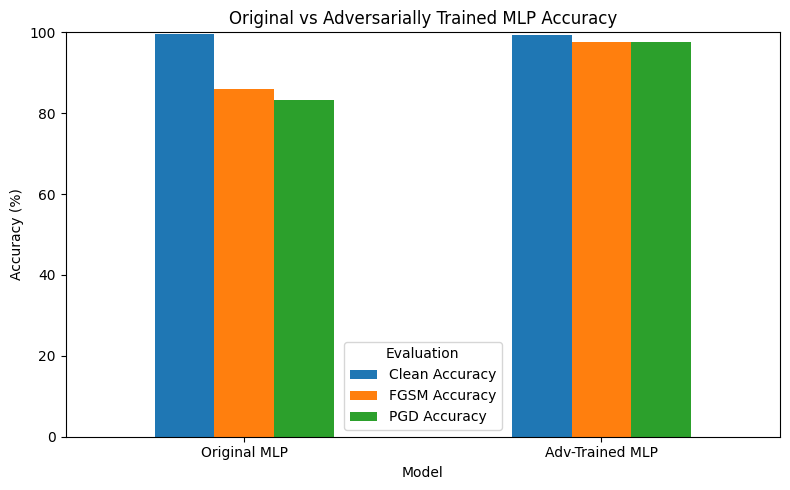

In [86]:
acc_df = plot_df[["Model", "Clean Accuracy", "FGSM Accuracy", "PGD Accuracy"]].set_index("Model")

ax = acc_df.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Accuracy (%)")
plt.title("Original vs Adversarially Trained MLP Accuracy")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Evaluation")
plt.tight_layout()
plt.savefig("adv_training_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

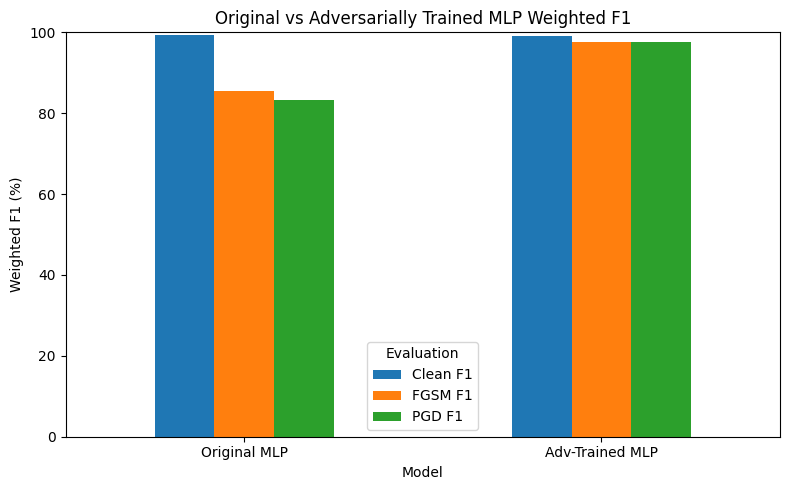

In [87]:
f1_df = plot_df[["Model", "Clean F1", "FGSM F1", "PGD F1"]].set_index("Model")

ax = f1_df.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Weighted F1 (%)")
plt.title("Original vs Adversarially Trained MLP Weighted F1")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Evaluation")
plt.tight_layout()
plt.savefig("adv_training_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [88]:
print('X_train' in globals())
print('mlp' in globals())
print('epsilon_sweep_df' in globals())

True
True
True


In [89]:
import pandas as pd
from pathlib import Path

for csv_file in Path(".").glob("*.csv"):
    try:
        df = pd.read_csv(csv_file, nrows=5)
        print(f"\n{csv_file.name}")
        print(df.columns.tolist()[-5:])  # show last few columns
    except Exception as e:
        print(csv_file.name, e)


adversarial_training_comparison.csv
['FGSM Accuracy', 'PGD Accuracy', 'Clean F1', 'FGSM F1', 'PGD F1']

epsilon_sweep_results.csv
['steps', 'accuracy', 'weighted_f1', 'macro_f1', 'notes']

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Friday-WorkingHours-Morning.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Monday-WorkingHours.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Tuesday-WorkingHours.pcap_ISCX.csv
['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']

Wednesday-workingHours.pcap_ISCX.c